In [4]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils import *
import numpy as np
import hyperspy.api as hs
import os
import matplotlib.pyplot as plt
import copy
from importlib import reload
from EDX import *
from skimage import data, img_as_float
from skimage import feature

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load all haadf images to inspect drift

In [18]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
edx, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame=False)
print(haadf.shape)

for z in range(haadf.shape[0])
    haadf_mm[z,:,:] = MinMax(haadf[z,:,:])

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)


In [67]:
for z in range(haadf.shape[0]):
    haadf_mm[z,:,:] = MinMax(haadf[z,:,:])

### Get and plot edges from different frames

Text(0.5, 1.0, 'Thresholded HAADF overlap (frame 00 and 03)')

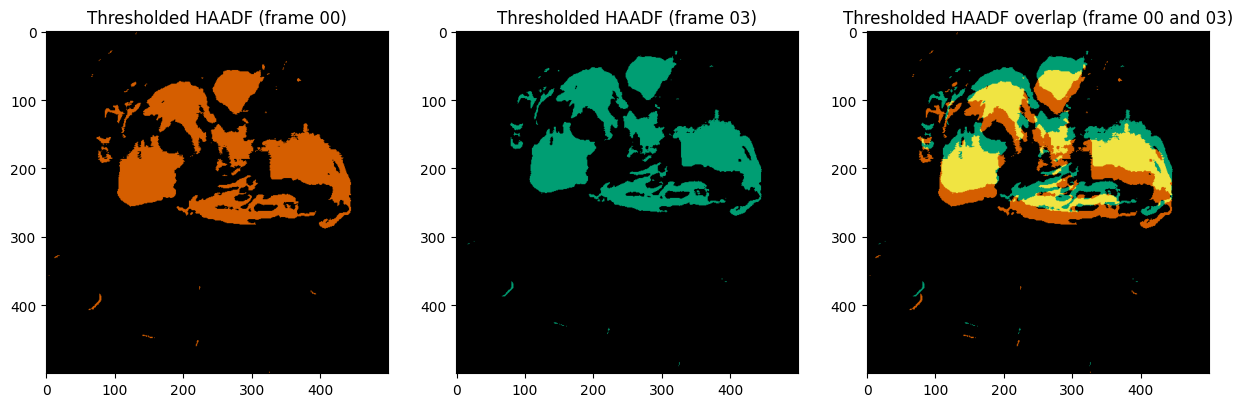

In [71]:
# colorblind colors
colors_cb = {
    "red":    {"hex": "#D55E00", "rgb": (213, 94, 0)},
    "green":  {"hex": "#009E73", "rgb": (0, 158, 115)},
    "yellow": {"hex": "#F0E442", "rgb": (240, 228, 66)},
}

# threshold
haadf_th = haadf_mm>0.5

# plot range
y1, y2, x1, x2 = [750, 1250, 250, 750] 

# frames 
f1, f2 = [0, 3]

# binarized images
img1b = haadf_th[f1,750:1250,250:750]
img2b = haadf_th[f2,750:1250,250:750]
img3b = img1b.astype('uint8') + img2b.astype('uint8')

# img dims
h, w = img1b.shape

# make appropraite images
img1 = np.zeros((h, w, 3), np.uint8)
img2 = np.zeros((h, w, 3), np.uint8)
img3 = np.zeros((h, w, 3), np.uint8)


img1[np.where(img1b)[0],np.where(img1b)[1],:] = colors_cb['red']['rgb']
img2[np.where(img2b)[0],np.where(img2b)[1],:] = colors_cb['green']['rgb']

# overlap image
img3[np.where(img1b)[0],np.where(img1b)[1],:] = colors_cb['red']['rgb']
img3[np.where(img2b)[0],np.where(img2b)[1],:] = colors_cb['green']['rgb']
img3[np.where(img3b==2)[0],np.where(img3b==2)[1],:] = colors_cb['yellow']['rgb']


# plot
f, ax = plt.subplots(1,3,figsize=(15,10))
ax[0].imshow(img1)
ax[0].set_title('Thresholded HAADF (frame %02d)' % f1)
ax[1].imshow(img2)
ax[1].set_title('Thresholded HAADF (frame %02d)' % f2)
ax[2].imshow(img3)
ax[2].set_title('Thresholded HAADF overlap (frame %02d and %02d)' % (f1,f2))



#ax[1].imshow(feature.canny(haadf_th[0,750:1250,250:750],sigma=0.8),cmap='gray')
#ax[0].title('Thresholded HAADF')

In [49]:
np.where(img3b==2)[0]

array([], dtype=int64)

In [51]:
img1b

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(500, 500))

In [39]:
colors_cb['red']['rgb']

(213, 94, 0)